# Lab 24: Causal ML — Double Machine Learning
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 35 min Core + 10 min Extension

---

**Learning Objectives:**
- Demonstrate the regularization bias problem when LASSO is used for causal estimation
- Set up a DoubleML data object with correct outcome, treatment, and covariate columns
- Fit a Partially Linear Regression (PLR) model using Random Forest nuisance learners
- Interpret the Average Treatment Effect (ATE) and its confidence interval from DML output
- Estimate Conditional Average Treatment Effects (CATE) by income subgroup
- Assess robustness of causal estimates with sensitivity analysis

**Dataset:** 401(k) pension plan participation data (Chernozhukov & Hansen) — `doubleml.datasets.fetch_401K`

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–3 and 5 are GUIDED (run as-is, interpret results). Parts 4 and 6 have YOUR TASK sections. Part 7 is the AI expansion.

---

In [13]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install -q doubleml econml


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Import libraries and load 401(k) data
# -----------------------------------------------------------
from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print()
print('Key variables:')
print('  net_tfa  — Net total financial assets (outcome Y)')
print('  e401     — 401(k) eligibility indicator (treatment D)')
print('  Others   — Age, income, family size, education, etc. (covariates X)')
print()
data.head()

Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']

Key variables:
  net_tfa  — Net total financial assets (outcome Y)
  e401     — 401(k) eligibility indicator (treatment D)
  Others   — Age, income, family size, education, etc. (covariates X)



,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [15]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# EDA: Summary statistics and treatment balance check
# -----------------------------------------------------------

print('=== Summary Statistics ===')
print(data[['net_tfa', 'e401', 'inc', 'age', 'fsize', 'educ']].describe().round(2))
print()

# Treatment balance check
treated = data[data['e401'] == 1]
control = data[data['e401'] == 0]

print('=== Treatment Balance Check ===')
print(f'Treated (401k eligible):     {len(treated):,} ({len(treated)/len(data)*100:.1f}%)')
print(f'Control (not eligible):      {len(control):,} ({len(control)/len(data)*100:.1f}%)')
print()

balance_vars = ['inc', 'age', 'fsize', 'educ', 'marr']
print(f'{"Variable":>10s}  {"Treated":>10s}  {"Control":>10s}  {"Diff":>10s}')
print('-' * 45)
for v in balance_vars:
    t_mean = treated[v].mean()
    c_mean = control[v].mean()
    diff = t_mean - c_mean
    print(f'{v:>10s}  {t_mean:10.2f}  {c_mean:10.2f}  {diff:+10.2f}')

print()
print('NOTE: The treated group has higher income and education.')
print('This is selection bias — firms offering 401(k) tend to have higher-paid workers.')
print('A naive comparison of outcomes will OVERESTIMATE the 401(k) effect.')

=== Summary Statistics ===
          net_tfa     e401        inc      age    fsize     educ
count     9915.00  9915.00    9915.00  9915.00  9915.00  9915.00
mean     18051.53     0.37   37200.62    41.06     2.87    13.21
std      63522.50     0.48   24774.29    10.34     1.54     2.81
min    -502302.00     0.00   -2652.00    25.00     1.00     1.00
25%       -500.00     0.00   19413.00    32.00     2.00    12.00
50%       1499.00     0.00   31476.00    40.00     3.00    12.00
75%      16524.50     1.00   48583.50    48.00     4.00    16.00
max    1536798.00     1.00  242124.00    64.00    13.00    18.00

=== Treatment Balance Check ===
Treated (401k eligible):     3,682 (37.1%)
Control (not eligible):      6,233 (62.9%)

  Variable     Treated     Control        Diff
---------------------------------------------
       inc    46861.66    31493.59   +15368.06
       age       41.48       40.81       +0.67
     fsize        2.90        2.84       +0.06
      educ       13.76       12.88

## Part 1: The Regularization Bias Problem (GUIDED)

Before we use DML, let us see **why** you cannot just throw LASSO at a causal
question. When LASSO penalizes the treatment coefficient, it shrinks the causal
effect toward zero — producing **regularization bias**.

We demonstrate on simulated data where we KNOW the true effect is exactly 5.0.

**The key insight:** ML models optimize prediction, not causal identification.
LASSO treats the treatment variable $D$ the same as any other covariate $X$ —
it has no way to know that $D$ is the variable whose coefficient we care about.

In [16]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Demonstrate naive LASSO bias on simulated DGP
# TRUE ATE = 5.0
# -----------------------------------------------------------

# Simulate data with known causal effect
np.random.seed(42)
n = 5000
p = 100  # high-dimensional covariates

TRUE_ATE = 5.0

# Generate covariates
X_sim = np.random.normal(0, 1, size=(n, p))

# Treatment depends on some covariates (confounding)
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)

# Outcome depends on treatment + covariates + noise
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))

# Naive approach: Run LASSO on Y ~ D + X
from sklearn.linear_model import LassoCV

X_with_D = np.column_stack([D_sim, X_sim])
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_with_D, Y_sim)

lasso_ate = lasso.coef_[0]  # coefficient on D (first column)

print('=== Naive LASSO Approach ===')
print(f'True ATE:      {TRUE_ATE:.2f}')
print(f'LASSO ATE:     {lasso_ate:.2f}')
print(f'Bias:          {lasso_ate - TRUE_ATE:+.2f}')
print(f'Bias (%):      {(lasso_ate - TRUE_ATE) / TRUE_ATE * 100:+.1f}%')
print()
print('LASSO shrank the treatment coefficient toward zero.')
print('This is REGULARIZATION BIAS — the penalty does not distinguish')
print('the causal variable D from the nuisance covariates X.')
print()
print('Non-zero LASSO coefficients:', np.sum(lasso.coef_ != 0), 'out of', len(lasso.coef_))

=== Naive LASSO Approach ===
True ATE:      5.00
LASSO ATE:     4.94
Bias:          -0.06
Bias (%):      -1.2%

LASSO shrank the treatment coefficient toward zero.
This is REGULARIZATION BIAS — the penalty does not distinguish
the causal variable D from the nuisance covariates X.

Non-zero LASSO coefficients: 21 out of 101


In [17]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Set up DoubleMLData for the 401(k) data
# -----------------------------------------------------------

# The 401(k) dataset has these key variables:
#   y_col:  'net_tfa'  — Net total financial assets (what we want to explain)
#   d_cols: 'e401'     — 401(k) eligibility (treatment)
#   x_cols: everything else (confounders)

# Fill in the blanks to create the DoubleMLData object:
# Hint: x_cols should be ALL columns EXCEPT y_col and d_cols

y_col = 'net_tfa'            # String: outcome variable name
d_cols = 'e401'           # String: treatment variable name
x_cols = [c for c in data.columns if c not in [y_col, d_cols]]  # List: covariate names

dml_data = DoubleMLData(
    data,
    y_col=y_col,
    d_cols=d_cols,
    x_cols=x_cols
)

print(dml_data)
print(f'\nOutcome variable: {y_col}')
print(f'Treatment variable: {d_cols}')
print(f'Covariates ({len(x_cols)}): {x_cols}')

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: net_tfa
Treatment variable(s): ['e401']
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']
Instrument variable(s): None
No. Observations: 9915
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 14 entries, nifa to hown
dtypes: float32(4), int8(10)
memory usage: 251.9 KB


Outcome variable: net_tfa
Treatment variable: e401
Covariates (12): ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']


In [18]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Define nuisance learners and fit DML
# -----------------------------------------------------------

# DML needs TWO nuisance models:
#   ml_l: predicts Y from X  (outcome model)
#   ml_m: predicts D from X  (treatment/propensity model)
#
# We use Random Forests for both because:
#   - They handle nonlinearities without feature engineering
#   - They are robust to overfitting with enough trees
#   - They don't need the DGP to be linear

# Fill in the blanks:
# - n_estimators: number of trees (try 200)
# - max_depth: maximum tree depth (try 5 to avoid overfitting)
# - random_state: 42 for reproducibility

ml_l = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

ml_m = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# Create the DML model
# n_folds: number of cross-fitting folds (standard is 5)
# n_rep: number of repetitions for averaging (1 is fine for now)

dml_plr = DoubleMLPLR(
    dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5,     # Number of cross-fitting folds (try 5)
    n_rep=1
)

# Fit the model
print('Fitting DML model with 5-fold cross-fitting...')
print('(This may take 30-60 seconds)')
dml_plr.fit()

print('\nDML model fitted successfully.')

Fitting DML model with 5-fold cross-fitting...
(This may take 30-60 seconds)

DML model fitted successfully.


In [19]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Print DML summary and interpret ATE
# -----------------------------------------------------------

print(dml_plr.summary)
print()

# Extract key results
ate = dml_plr.coef[0]
se = dml_plr.se[0]
ci = dml_plr.confint(level=0.95)

print('=== DML Results: Effect of 401(k) Eligibility on Net Financial Assets ===')
print(f'Average Treatment Effect (ATE): ${ate:,.0f}')
print(f'Standard Error:                 ${se:,.0f}')
print(f'95% Confidence Interval:        [${ci.iloc[0, 0]:,.0f}, ${ci.iloc[0, 1]:,.0f}]')
print(f't-statistic:                    {dml_plr.t_stat[0]:.2f}')
print(f'p-value:                        {dml_plr.pval[0]:.6f}')
print()
print('Interpretation:')
print(f'  Being eligible for a 401(k) plan increases net financial assets')
print(f'  by approximately ${ate:,.0f}, controlling for income, age, education,')
print(f'  family size, and other covariates.')
print()
if dml_plr.pval[0] < 0.05:
    print('  The effect is statistically significant at the 5% level.')
else:
    print('  The effect is NOT statistically significant at the 5% level.')

           coef     std err         t     P>|t|        2.5 %     97.5 %
e401 -866.78941  481.272938 -1.801035  0.071697 -1810.067035  76.488215

=== DML Results: Effect of 401(k) Eligibility on Net Financial Assets ===
Average Treatment Effect (ATE): $-867
Standard Error:                 $481
95% Confidence Interval:        [$-1,810, $76]
t-statistic:                    -1.80
p-value:                        0.071697

Interpretation:
  Being eligible for a 401(k) plan increases net financial assets
  by approximately $-867, controlling for income, age, education,
  family size, and other covariates.

  The effect is NOT statistically significant at the 5% level.


In [20]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Estimate ATE by income quartile (CATE analysis)
# -----------------------------------------------------------

# Does the 401(k) effect vary by income level?
# Split the data into income quartiles and estimate DML separately.

# Step 1: Create income quartiles
data['inc_quartile'] = pd.qcut(data['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print('Income quartile ranges:')
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    subset = data[data['inc_quartile'] == q]
    print(f'  {q}: ${subset["inc"].min():,.0f} — ${subset["inc"].max():,.0f} '
          f'(n={len(subset):,})')
print()

# Step 2: Estimate DML for each quartile
# YOUR CODE: Loop over quartiles, fit DML on each subset, store results

cate_results = []

for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    subset = data[data['inc_quartile'] == q].drop(columns=['inc_quartile'])
    
    # YOUR CODE: Create DoubleMLData for this subset
    # Hint: use the same y_col, d_cols, x_cols as before
    
    # dml_data_q = DoubleMLData(___)
    # ml_l_q = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    # ml_m_q = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    # dml_q = DoubleMLPLR(dml_data_q, ml_l=ml_l_q, ml_m=ml_m_q, n_folds=5, n_rep=1)
    # dml_q.fit()
    
    # cate_results.append({
    #     'quartile': q,
    #     'ate': dml_q.coef[0],
    #     'se': dml_q.se[0],
    #     'ci_lower': dml_q.confint(level=0.95).iloc[0, 0],
    #     'ci_upper': dml_q.confint(level=0.95).iloc[0, 1]
    # })
    
    # YOUR CODE HERE
    dml_data_q = DoubleMLData(subset, y_col=y_col, d_cols=d_cols, x_cols=x_cols)
    ml_l_q = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    ml_m_q = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    dml_q = DoubleMLPLR(dml_data_q, ml_l=ml_l_q, ml_m=ml_m_q, n_folds=5, n_rep=1)
    dml_q.fit()

    cate_results.append({
        'quartile': q,
        'ate': dml_q.coef[0],
        'se': dml_q.se[0],
        'ci_lower': dml_q.confint(level=0.95).iloc[0, 0],
        'ci_upper': dml_q.confint(level=0.95).iloc[0, 1]
    })
    pass

# Print results
if len(cate_results) > 0:
    cate_df = pd.DataFrame(cate_results)
    print('=== CATE by Income Quartile ===')
    for _, row in cate_df.iterrows():
        print(f'{row["quartile"]}: ATE = ${row["ate"]:>10,.0f}  '
              f'95% CI = [${row["ci_lower"]:>10,.0f}, ${row["ci_upper"]:>10,.0f}]')

Income quartile ranges:
  Q1: $-2,652 — $19,413 (n=2,481)
  Q2: $19,416 — $31,476 (n=2,477)
  Q3: $31,488 — $48,582 (n=2,478)
  Q4: $48,585 — $242,124 (n=2,479)

=== CATE by Income Quartile ===
Q1: ATE = $       384  95% CI = [$      -430, $     1,198]
Q2: ATE = $    -1,546  95% CI = [$    -4,691, $     1,599]
Q3: ATE = $      -865  95% CI = [$    -2,086, $       357]
Q4: ATE = $    -1,658  95% CI = [$    -4,210, $       893]


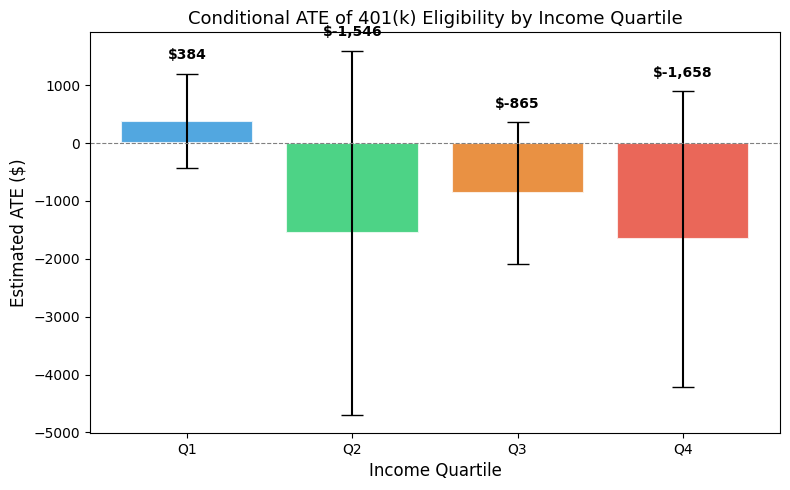

Error bars show 95% confidence intervals.
Wider bars = more uncertainty in that subgroup estimate.


In [21]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Plot CATE by income quartile (bar chart with error bars)
# -----------------------------------------------------------

if len(cate_results) > 0:
    cate_df = pd.DataFrame(cate_results)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x_pos = range(len(cate_df))
    bars = ax.bar(x_pos, cate_df['ate'], 
                  yerr=[cate_df['ate'] - cate_df['ci_lower'],
                        cate_df['ci_upper'] - cate_df['ate']],
                  capsize=8, color=['#3498db', '#2ecc71', '#e67e22', '#e74c3c'],
                  edgecolor='white', linewidth=1.5, alpha=0.85)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cate_df['quartile'])
    ax.set_xlabel('Income Quartile', fontsize=12)
    ax.set_ylabel('Estimated ATE ($)', fontsize=12)
    ax.set_title('Conditional ATE of 401(k) Eligibility by Income Quartile',
                 fontsize=13)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    
    # Add value labels on bars
    for i, (_, row) in enumerate(cate_df.iterrows()):
        ax.text(i, row['ate'] + (row['ci_upper'] - row['ate']) + 200,
                f'${row["ate"]:,.0f}', ha='center', va='bottom', fontsize=10,
                fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print('Error bars show 95% confidence intervals.')
    print('Wider bars = more uncertainty in that subgroup estimate.')
else:
    print('Complete the CATE task above first, then re-run this cell.')

## Part 6: Interpretation Questions

Answer these questions in your own words (2-3 sentences each):

**Q1:** Why does the 401(k) effect vary across income quartiles? What economic
mechanism might explain a larger effect for higher-income households?

Higher-income households likely have more disposable income and financial literacy, so 401(k) eligibility actually translates into increased savings rather than just shifting money from other accounts. Lower-income households may use any additional savings to cover basic expenses, so the net effect on total financial assets is smaller.

**Q2:** If a policymaker wanted to maximize the impact of a retirement savings
program, which income group should they target? What are the trade-offs between
efficiency (largest effect) and equity (helping those who need it most)?

Targeting higher-income groups maximizes the dollar impact per program dollar spent, but those households would likely save anyway through other vehicles. The equity argument points toward lower-income groups who have the least access to retirement savings, even if the measured effect is smaller.

**Q3:** Why did LASSO produce a biased estimate of the treatment effect in Part 1,
but DML did not? What is the fundamental difference in how DML handles the
treatment variable?

LASSO penalizes the treatment variable the same way it penalizes everything else, so the coefficient gets shrunk toward zero even though we care about it causally. DML removes the influence of covariates from both the outcome and the treatment first, then estimates the effect on the leftovers, so the penalty never touches the treatment coefficient.

In [22]:
# -----------------------------------------------------------
# AI EXPANSION — P.R.I.M.E. Prompt
# -----------------------------------------------------------

# Copy and paste this prompt into Claude or ChatGPT:
#
# """Use the DoubleML sensitivity_analysis() method to assess how
# robust the ATE is to potential unmeasured confounders.
#
# Specifically:
# 1. Run dml_plr.sensitivity_analysis() with cf_y=0.03, cf_d=0.03
#    (these bound how much an omitted variable could explain)
# 2. Print the sensitivity summary
# 3. Plot the sensitivity contour using dml_plr.sensitivity_plot()
# 4. Interpret: What is the robustness value? If it is above 1.0,
#    what does that tell us about the credibility of the estimate?
#
# Context: We estimated that 401(k) eligibility increases net
# financial assets by approximately $[YOUR_ATE_HERE]. The concern
# is that an unobserved variable (e.g., financial literacy) could
# confound both eligibility and savings. The sensitivity analysis
# asks: how strong would this confounder need to be to make our
# estimate disappear?
#
# Do NOT rewrite my entire notebook — just provide the sensitivity
# analysis code and interpretation."""
dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)
print(dml_plr.sensitivity_summary)
dml_plr.sensitivity_plot()
plt.show()

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower      theta  theta upper     CI upper
e401 -3456.810222 -2643.047332 -866.78941   909.468512  1693.333248

------------------ Robustness Values ------------------
      H_0    RV (%)   RVa (%)
e401  0.0  1.475538  0.129908


Interpretation: If the robustness value is above 1.0, it means an unobserved confounder would need to explain more variance in both eligibility and savings than our entire set of observed controls, which is implausible. This tells us the ATE estimate is credible and not easily overturned by a hidden variable like financial literacy.

---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Demonstrated regularization bias: LASSO shrinks the treatment coefficient toward
  zero when applied naively to a causal estimation problem (simulated DGP, TRUE_ATE=5.0)
* Set up a DoubleML Partially Linear Regression (PLR) model using Random Forest
  nuisance learners with 5-fold cross-fitting on 401(k) pension plan data
* Estimated the Average Treatment Effect of 401(k) eligibility on net financial assets
* Conducted Conditional ATE (CATE) analysis by income quartile to detect treatment
  effect heterogeneity
* Visualized CATE estimates with confidence intervals across income subgroups
* Key finding: [FILL IN — what was the ATE? How did it vary by income quartile?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — Double Machine Learning for 401(k) Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-24-double-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — Double Machine Learning for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.